In [1]:
import pandas as pd
import numpy as np

from antlr4 import InputStream, CommonTokenStream, Token
from antlr4.error.ErrorListener import ErrorListener

In [2]:
import sys
from pathlib import Path

STL_DIR = (Path.cwd() / "../src/external/PyTeLo/stl").resolve()
print(Path.cwd())
print(STL_DIR, STL_DIR.exists())   # must print True

sys.path.insert(0, str(STL_DIR))

from antlr4 import InputStream, CommonTokenStream, Token
from antlr4.error.ErrorListener import ErrorListener
from stlLexer import stlLexer
from stlParser import stlParser
from stl import Operation, RelOperation, STLAbstractSyntaxTreeExtractor, to_ast

/Users/em_paula_iv/Documents/GitHub/ATIC_NL_STL/ATIC_Backtranslation
/Users/em_paula_iv/Documents/GitHub/ATIC_NL_STL/src/external/PyTeLo/stl True


In [3]:
df = pd.read_csv("../ATIC_Dataset/nl_stl_benchmark_150.csv")

In [4]:
NL_COL  = "requirement_nl"     # <- EDIT: column with the natural-language statement
STL_COL = "gold_stl"    # <- EDIT: column with the STL formula

In [5]:
import matplotlib.pyplot as plt

# ---------- strict parsing (raises on syntax errors / trailing junk) ----------
class RaiseOnError(ErrorListener):
    def syntaxError(self, recognizer, offendingSymbol, line, column, msg, e):
        raise SyntaxError(f"col {column}: {msg}")

def parse_strict(formula: str):
    lexer = stlLexer(InputStream(formula))
    lexer.removeErrorListeners(); lexer.addErrorListener(RaiseOnError())
    parser = stlParser(CommonTokenStream(lexer))
    parser.removeErrorListeners(); parser.addErrorListener(RaiseOnError())
    tree = parser.stlProperty()
    if parser.getCurrentToken().type != Token.EOF:
        raise SyntaxError(f"unparsed trailing input: {parser.getCurrentToken().text!r}")
    return STLAbstractSyntaxTreeExtractor().visit(tree)

# ---------- AST helpers ----------
def kids(n):
    if n.op in (Operation.AND, Operation.OR):
        return list(n.children)
    if n.op in (Operation.IMPLIES, Operation.UNTIL):
        return [n.left, n.right]
    if n.op in (Operation.NOT, Operation.ALWAYS, Operation.EVENT):
        return [n.child]
    return []

def label(n):
    if n.op == Operation.BOOL:
        return str(n.value)
    if n.op == Operation.PRED:
        return f"{n.variable} {RelOperation.getString(n.relation)} {n.threshold}"
    name = Operation.getName(n.op).upper()
    if n.op in (Operation.ALWAYS, Operation.EVENT, Operation.UNTIL):
        return f"{name}\n[{n.low:g}, {n.high:g}]"
    return name

# ---------- text tree ----------
def print_tree(n, prefix="", is_last=True, is_root=True):
    text = label(n).replace("\n", " ")
    if is_root:
        print(text); child_prefix = ""
    else:
        print(prefix + ("└── " if is_last else "├── ") + text)
        child_prefix = prefix + ("    " if is_last else "│   ")
    ch = kids(n)
    for i, c in enumerate(ch):
        print_tree(c, child_prefix, i == len(ch) - 1, is_root=False)

# ---------- drawn tree (matplotlib only, no extra installs) ----------
def draw_ast(root, title=None):
    pos, counter = {}, [0]

    def layout(n, depth=0):
        ch = kids(n)
        if not ch:
            x = counter[0]; counter[0] += 1
        else:
            xs = [layout(c, depth + 1) for c in ch]
            x = sum(xs) / len(xs)
        pos[id(n)] = (x, -depth)
        return x
    layout(root)

    max_depth = -min(y for _, y in pos.values())
    fig, ax = plt.subplots(figsize=(max(5, counter[0] * 2.2), max(2.5, (max_depth + 1) * 1.3)))

    def colour(n):
        if n.op in (Operation.ALWAYS, Operation.EVENT, Operation.UNTIL): return "#cfe8ff"   # temporal
        if n.op in (Operation.PRED, Operation.BOOL):                      return "#d9f2d9"   # leaves
        return "#ffe5b4"                                                                      # logical

    def draw(n):
        x, y = pos[id(n)]
        for c in kids(n):
            cx, cy = pos[id(c)]
            ax.plot([x, cx], [y, cy], color="gray", zorder=1)
            draw(c)
        ax.text(x, y, label(n), ha="center", va="center", fontsize=10, zorder=2,
                bbox=dict(boxstyle="round,pad=0.35", fc=colour(n), ec="black"))
    draw(root)

    ax.set_xlim(-0.7, max(counter[0] - 1, 0) + 0.7)
    ax.set_ylim(-max_depth - 0.6, 0.6)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10)
    plt.show()

row 0
NL : Whenever V_In is greater than 5, V_Out must become smaller than 2 within the next 10 time units.
STL: G((V_In > 5) -> F[0,10](V_Out < 2))
!! parse failed: SyntaxError: col 1: mismatched input '(' expecting '['
row 1
NL : Whenever Op_Cmd changes to Passive, Spd_Act must become 0 within at most 500 time units.
STL: G(rise(Op_Cmd = Passive) -> F[0,500](Spd_Act = 0))
!! parse failed: SyntaxError: col 1: mismatched input '(' expecting '['
row 2
NL : Whenever V_Mot enters the interval from 1 to 12, Spd_Act must enter the interval from 100 to 1000 within 100 time units.
STL: G(rise((V_Mot >= 1) & (V_Mot <= 12)) -> F[0,100]((Spd_Act >= 100) & (Spd_Act <= 1000)))
!! parse failed: SyntaxError: col 1: mismatched input '(' expecting '['
row 3
NL : Whenever reaction-wheel angular momentum is greater than 0.35, reaction-wheel torque must equal 0.
STL: G((RWs_angular_momentum > 0.35) -> (RWs_torque = 0))
!! parse failed: SyntaxError: col 1: mismatched input '(' expecting '['
row 4
NL : Dur

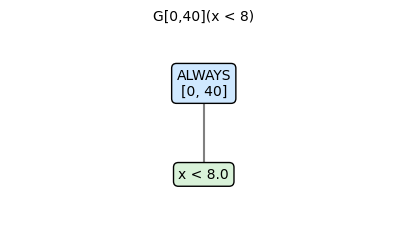

row 5
NL : The coolant temperature must stay below 95, oil pressure above 15, and battery voltage above 11 at all times.
STL: G((coolant_temp < 95) & (oil_pressure > 15) & (battery_voltage > 11))
!! parse failed: SyntaxError: col 1: mismatched input '(' expecting '['
row 6
NL : At all times, at least one of the primary, secondary, or emergency pump must be running.
STL: G((pump_primary = 1) | (pump_secondary = 1) | (pump_emergency = 1))
!! parse failed: SyntaxError: col 1: mismatched input '(' expecting '['
row 7
NL : Within 8 seconds, both the valve must be open and pressure must be below 6.
STL: F[0,8]((valve_open = 1) & (pressure < 6))
Error: unknown operation!
AST (normalised): (F[0.0, 8.0] None)
EVENT [0, 8]
!! parse failed: AttributeError: 'NoneType' object has no attribute 'op'
row 8
NL : For the next 15 seconds, speed must be below 10 or the emergency brake must be active.
STL: G[0,15]((speed < 10) | (emergency_brake = 1))
Error: unknown operation!
AST (normalised): (G[0.0, 15.

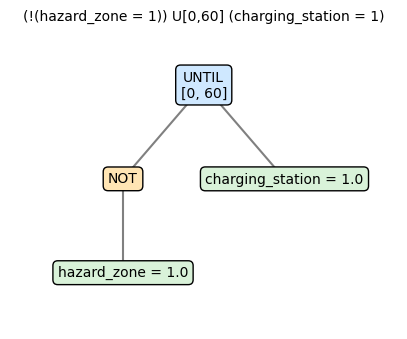

row 12
NL : Whenever reset is issued, the fault flag must have been false throughout the preceding 5 seconds.
STL: G((reset = 1) -> H[0,5](fault = 0))
!! parse failed: SyntaxError: col 1: mismatched input '(' expecting '['
row 13
NL : The warning must have remained active since the most recent loss-of-signal event.
STL: (warning = 1) S (loss_of_signal = 1)
!! parse failed: SyntaxError: unparsed trailing input: 'S'
row 14
NL : Whenever enable rises, output must turn on within 1 second; whenever enable falls, output must turn off within 1 second.
STL: G(rise(enable = 1) -> F[0,1](output = 1)) & G(fall(enable = 1) -> F[0,1](output = 0))
!! parse failed: SyntaxError: col 1: mismatched input '(' expecting '['
row 15
NL : If wheel slip ratio exceeds 0.18 on a low-µ surface, reduce demanded longitudinal torque within 120 milliseconds.
STL: G(((slip_ratio > 0.18) & (road_friction < 0.4)) -> F[0,0.12](demanded_torque < torque_limit))
!! parse failed: SyntaxError: col 1: mismatched input '(' exp

In [7]:
N = 20   # how many examples

for i, row in df.head(N).iterrows():
    nl, stl_str = row[NL_COL], str(row[STL_COL])
    print("=" * 80)
    print(f"row {i}")
    print("NL :", nl)
    print("STL:", stl_str)
    try:
        ast = parse_strict(stl_str)
        print("AST (normalised):", ast)
        print_tree(ast)
        draw_ast(ast, title=stl_str)
    except Exception as e:
        print(f"!! parse failed: {type(e).__name__}: {e}")